# product level data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import warnings

df = pd.read_csv("online retail cleaned.csv", parse_dates=['InvoiceDate'])

# Date range
date_range = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days
print(f"Data spans {date_range} days")

# Product level aggregation
product_df = df.groupby('StockCode').agg(
    ProductName    = ('Description',  'first'),
    TotalSold      = ('Quantity',      'sum'),
    TotalRevenue   = ('Total Price',    'sum'),
    AvgPrice       = ('Price',         'mean'),
    OrderCount     = ('Invoice',       'nunique'),
    UniqueCustomers= ('Customer ID',   'nunique')
).reset_index()

# Daily demand calculate karo
product_df['AvgDailyDemand'] = product_df['TotalSold'] / date_range

# Demand variability (std dev per day)
daily_product = df.groupby(['StockCode',
                 df['InvoiceDate'].dt.date])['Quantity'].sum().reset_index()
daily_product.columns = ['StockCode', 'Date', 'DailyQty']

demand_std = daily_product.groupby('StockCode')['DailyQty'].std().reset_index()
demand_std.columns = ['StockCode', 'DemandStdDev']

product_df = product_df.merge(demand_std, on='StockCode', how='left')
product_df['DemandStdDev'] = product_df['DemandStdDev'].fillna(0)

print(f"Total products: {len(product_df)}")
print(product_df.head())

Data spans 373 days
Total products: 3989
  StockCode                  ProductName  TotalSold  TotalRevenue  AvgPrice  \
0     10002  INFLATABLE POLITICAL GLOBE        2616       2207.22  0.847222   
1     10080     GROOVY CACTUS INFLATABLE         12         10.20  0.850000   
2     10109         BENDY COLOUR PENCILS          4          1.68  0.420000   
3     10120                 DOGGY RUBBER        411         86.31  0.210000   
4    10123C        HEARTS WRAPPING TAPE         240        156.00  0.650000   

   OrderCount  UniqueCustomers  AvgDailyDemand  DemandStdDev  
0         229              145        7.013405     13.266120  
1           5                4        0.032172      2.190890  
2           1                1        0.010724      0.000000  
3          35               32        1.101877     12.197592  
4          41               34        0.643432      5.941632  


In [4]:
ORDERING_COST = 10       # £ per order place karne ka cost
HOLDING_RATE  = 0.20     # 20% of unit price per year

product_df['AnnualDemand'] = product_df['AvgDailyDemand'] * 365
product_df['HoldingCost']  = product_df['AvgPrice'] * HOLDING_RATE

# EOQ calculate  — zero division avoid 
product_df['EOQ'] = np.where(
    product_df['HoldingCost'] > 0,
    np.sqrt((2 * product_df['AnnualDemand'] * ORDERING_COST)
             / product_df['HoldingCost']),
    0
).round(0)

print(product_df[['StockCode','ProductName','AnnualDemand',
                   'EOQ','AvgPrice']].head(10))

  StockCode                   ProductName  AnnualDemand    EOQ  AvgPrice
0     10002   INFLATABLE POLITICAL GLOBE    2559.892761  550.0  0.847222
1     10080      GROOVY CACTUS INFLATABLE     11.742627   37.0  0.850000
2     10109          BENDY COLOUR PENCILS      3.914209   31.0  0.420000
3     10120                  DOGGY RUBBER    402.184987  438.0  0.210000
4    10123C         HEARTS WRAPPING TAPE     234.852547  190.0  0.650000
5    10123G       ARMY CAMO WRAPPING TAPE     37.184987   76.0  0.650000
6    10124A   SPOTS ON RED BOOKCOVER TAPE     45.013405  104.0  0.420000
7    10124G      ARMY CAMO BOOKCOVER TAPE     19.571046   68.0  0.420000
8     10125       MINI FUNKY DESIGN TAPES    771.099196  301.0  0.850000
9     10133  COLOURING PENCILS BROWN TUBE    799.477212  307.0  0.847011


In [5]:
# Reorder point calculate

In [6]:
LEAD_TIME     = 7     # days — supplier se delivery time
SERVICE_LEVEL = 1.65  # 95% service level (Z-score)

# Safety Stock
product_df['SafetyStock'] = (
    SERVICE_LEVEL
    * product_df['DemandStdDev']
    * np.sqrt(LEAD_TIME)
).round(0)

# Reorder Point
product_df['ReorderPoint'] = (
    product_df['AvgDailyDemand'] * LEAD_TIME
    + product_df['SafetyStock']
).round(0)

print(product_df[['StockCode','ProductName','AvgDailyDemand',
                   'SafetyStock','ReorderPoint','EOQ']].head(10))

  StockCode                   ProductName  AvgDailyDemand  SafetyStock  \
0     10002   INFLATABLE POLITICAL GLOBE         7.013405         58.0   
1     10080      GROOVY CACTUS INFLATABLE        0.032172         10.0   
2     10109          BENDY COLOUR PENCILS        0.010724          0.0   
3     10120                  DOGGY RUBBER        1.101877         53.0   
4    10123C         HEARTS WRAPPING TAPE         0.643432         26.0   
5    10123G       ARMY CAMO WRAPPING TAPE        0.101877         18.0   
6    10124A   SPOTS ON RED BOOKCOVER TAPE        0.123324          9.0   
7    10124G      ARMY CAMO BOOKCOVER TAPE        0.053619          7.0   
8     10125       MINI FUNKY DESIGN TAPES        2.112601         53.0   
9     10133  COLOURING PENCILS BROWN TUBE        2.190349         41.0   

   ReorderPoint    EOQ  
0         107.0  550.0  
1          10.0   37.0  
2           0.0   31.0  
3          61.0  438.0  
4          31.0  190.0  
5          19.0   76.0  
6         

In [7]:
# ABC ANalysis product categorized

In [8]:
# Revenue ke basis pe sort 
product_df = product_df.sort_values('TotalRevenue', ascending=False)
product_df['CumulativeRevenue'] = product_df['TotalRevenue'].cumsum()
product_df['CumulativePct']     = (product_df['CumulativeRevenue']
                                   / product_df['TotalRevenue'].sum() * 100)

# ABC categories assign 
def abc_category(pct):
    if pct <= 70:
        return 'A'   # Top 70% revenue — most important
    elif pct <= 90:
        return 'B'   # Next 20% revenue
    else:
        return 'C'   # Last 10% revenue — least important

product_df['ABC_Category'] = product_df['CumulativePct'].apply(abc_category)

print(product_df['ABC_Category'].value_counts())
print("\nRevenue by Category:")
print(product_df.groupby('ABC_Category')['TotalRevenue'].sum())

ABC_Category
C    2576
B     813
A     600
Name: count, dtype: int64

Revenue by Category:
ABC_Category
A    4176123.050
B    1192570.670
C     597265.814
Name: TotalRevenue, dtype: float64


# visualization

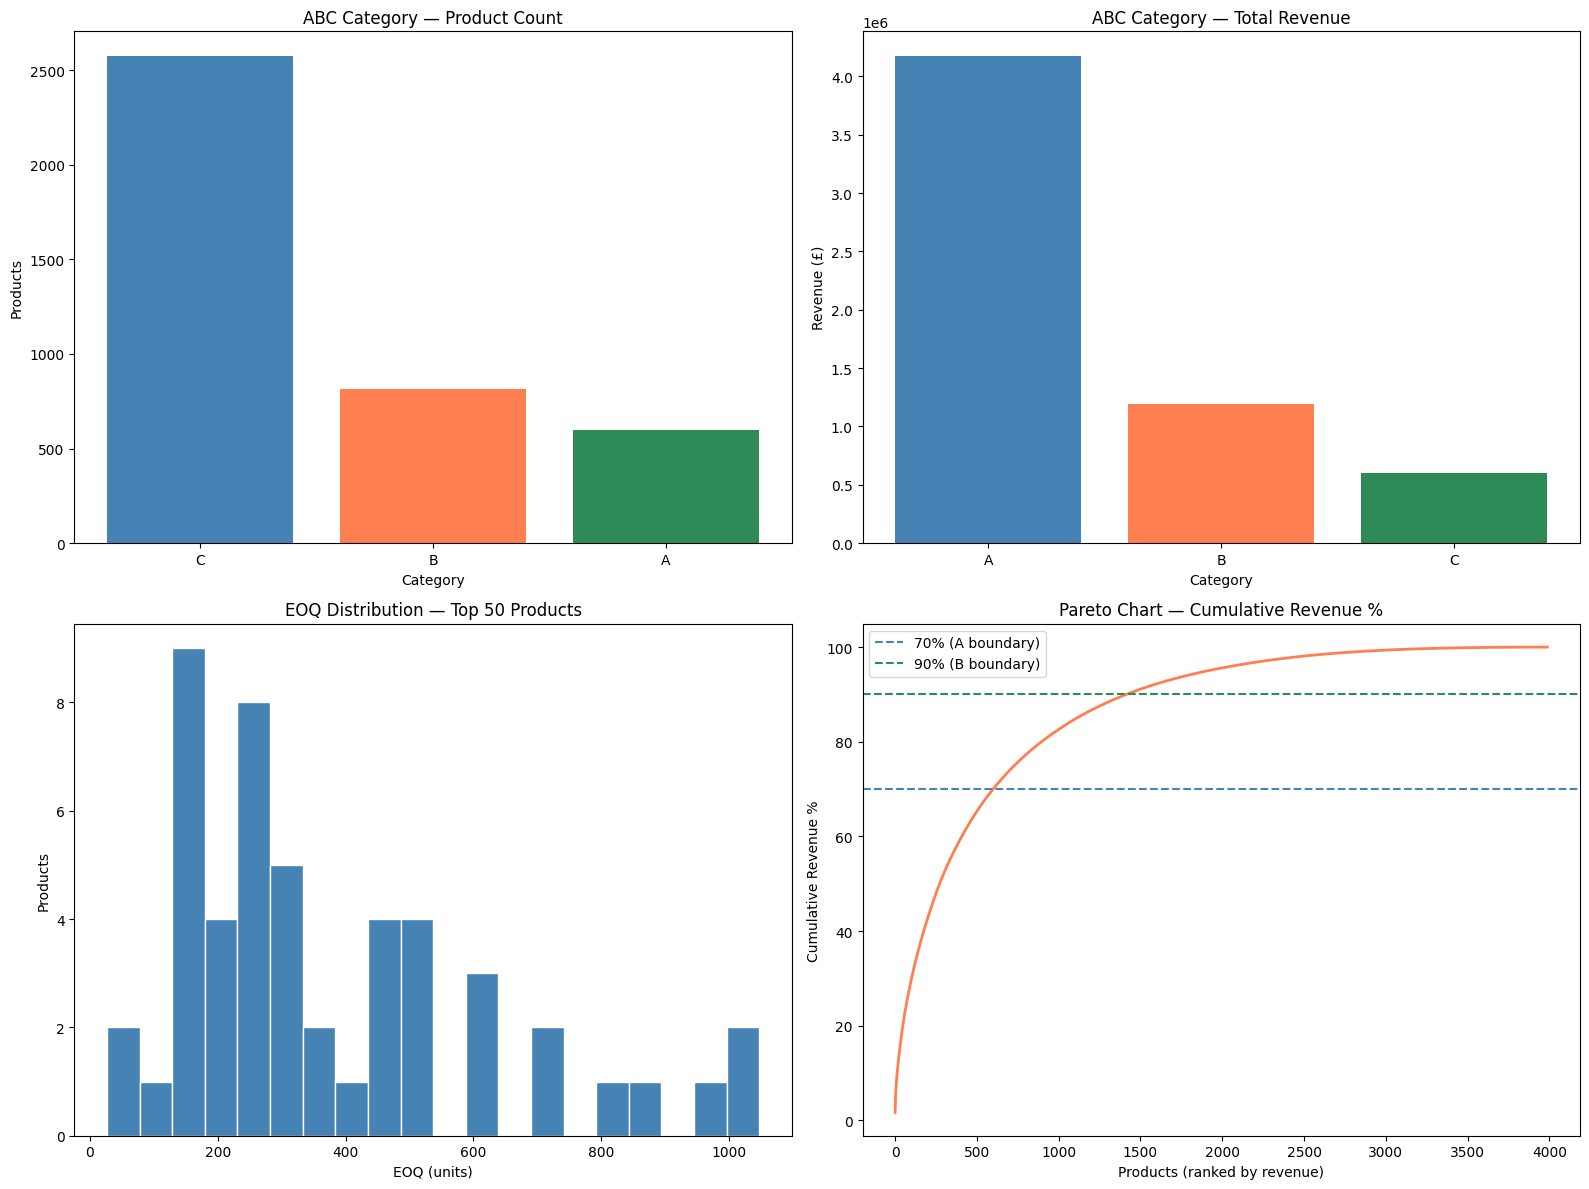

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ABC Category distribution
abc_counts = product_df['ABC_Category'].value_counts()
axes[0,0].bar(abc_counts.index, abc_counts.values,
              color=['steelblue','coral','seagreen'])
axes[0,0].set_title("ABC Category — Product Count")
axes[0,0].set_xlabel("Category")
axes[0,0].set_ylabel("Products")

# 2. Revenue by ABC
abc_rev = product_df.groupby('ABC_Category')['TotalRevenue'].sum()
axes[0,1].bar(abc_rev.index, abc_rev.values,
              color=['steelblue','coral','seagreen'])
axes[0,1].set_title("ABC Category — Total Revenue")
axes[0,1].set_xlabel("Category")
axes[0,1].set_ylabel("Revenue (£)")

# 3. EOQ distribution — top 50 products
top50 = product_df.nlargest(50, 'TotalRevenue')
axes[1,0].hist(top50['EOQ'], bins=20,
               color='steelblue', edgecolor='white')
axes[1,0].set_title("EOQ Distribution — Top 50 Products")
axes[1,0].set_xlabel("EOQ (units)")
axes[1,0].set_ylabel("Products")

# 4. Pareto Chart — Cumulative revenue
axes[1,1].plot(range(len(product_df)),
               product_df['CumulativePct'].values,
               color='coral', linewidth=2)
axes[1,1].axhline(y=70, color='steelblue', linestyle='--',
                   label='70% (A boundary)')
axes[1,1].axhline(y=90, color='seagreen', linestyle='--',
                   label='90% (B boundary)')
axes[1,1].set_title("Pareto Chart — Cumulative Revenue %")
axes[1,1].set_xlabel("Products (ranked by revenue)")
axes[1,1].set_ylabel("Cumulative Revenue %")
axes[1,1].legend()

plt.tight_layout()
plt.savefig("plots/inventory_analysis.png")
plt.show()

# Stock Status idetify

In [10]:
# Assume current stock = 30 days ka average demand
# (real data mein actual stock hoga)
product_df['CurrentStock'] = (product_df['AvgDailyDemand'] * 30).round(0)

# Stock status
def stock_status(row):
    if row['CurrentStock'] <= row['SafetyStock']:
        return 'CRITICAL'       # Turant order karo
    elif row['CurrentStock'] <= row['ReorderPoint']:
        return 'REORDER NOW'    # Order place karo
    elif row['CurrentStock'] <= row['ReorderPoint'] * 1.5:
        return 'MONITOR'        # Dhyan rakho
    else:
        return 'OK'             # Stock theek hai

product_df['StockStatus'] = product_df.apply(stock_status, axis=1)

print("\nStock Status Summary:")
print(product_df['StockStatus'].value_counts())


Stock Status Summary:
StockStatus
CRITICAL       2404
OK              716
MONITOR         575
REORDER NOW     294
Name: count, dtype: int64


In [11]:
# those are being oder
urgent_orders = product_df[
    product_df['StockStatus'].isin(['CRITICAL', 'REORDER NOW'])
].sort_values('TotalRevenue', ascending=False)

print(f"\nProducts needing immediate order: {len(urgent_orders)}")
print("\nTop 15 Urgent Orders:")
print(urgent_orders[[
    'StockCode', 'ProductName', 'StockStatus',
    'CurrentStock', 'ReorderPoint', 'EOQ', 'ABC_Category'
]].head(15).to_string())


Products needing immediate order: 2698

Top 15 Urgent Orders:
     StockCode                          ProductName  StockStatus  CurrentStock  ReorderPoint    EOQ ABC_Category
1049     21769          VINTAGE POST OFFICE CABINET     CRITICAL          10.0          31.0   12.0            A
2089     22946         WOODEN ADVENT CALENDAR CREAM     CRITICAL          41.0          52.0   55.0            A
2084     22941         CHRISTMAS LIGHTS 10 REINDEER     CRITICAL          69.0         105.0   99.0            A
690      21340  CLASSIC METAL BIRDCAGE PLANT HOLDER  REORDER NOW          45.0          48.0   67.0            A
1813     22656         VINTAGE BLUE KITCHEN CABINET     CRITICAL           2.0           2.0    3.0            A
3404     85067        CREAM SWEETHEART WALL CABINET  REORDER NOW          23.0          24.0   39.0            A
1020     21735               TWO DOOR CURIO CABINET     CRITICAL          33.0          42.0   57.0            A
1812     22655          VINTAGE R

In [13]:
# Full inventory report
product_df.to_csv("inventory_optimization.csv", index=False)

# Urgent orders separately
urgent_orders.to_csv("urgent_orders.csv", index=False)

# Final summary
print("\n========== INVENTORY SUMMARY ==========")
print(f"Total Products Analyzed : {len(product_df)}")
print(f"Category A (Critical)   : {(product_df['ABC_Category']=='A').sum()}")
print(f"Category B (Important)  : {(product_df['ABC_Category']=='B').sum()}")
print(f"Category C (Low value)  : {(product_df['ABC_Category']=='C').sum()}")
print(f"\nStock Status:")
print(f"  CRITICAL    : {(product_df['StockStatus']=='CRITICAL').sum()}")
print(f"  REORDER NOW : {(product_df['StockStatus']=='REORDER NOW').sum()}")
print(f"  MONITOR     : {(product_df['StockStatus']=='MONITOR').sum()}")
print(f"  OK          : {(product_df['StockStatus']=='OK').sum()}")
print("=========================================")


========== INVENTORY SUMMARY ==========
Total Products Analyzed : 3989
Category A (Critical)   : 600
Category B (Important)  : 813
Category C (Low value)  : 2576

Stock Status:
  CRITICAL    : 2404
  REORDER NOW : 294
  MONITOR     : 575
  OK          : 716
